# ⚙️ Wisconsin Dataset - Feature Engineering & Selection

## Mục tiêu
- Feature importance từ nhiều perspectives
- Recursive Feature Elimination (RFE)
- Principal Component Analysis (PCA)
- Feature interaction analysis
- Dimensionality reduction comparison
- Tạo tập features tối ưu

## 🎯 Tại sao Feature Engineering quan trọng?

**Benefits:**
- ✅ Giảm overfitting (fewer features)
- ✅ Tăng tốc độ training & inference
- ✅ Dễ giải thích hơn (less complexity)
- ✅ Có thể tăng performance

**Approaches:**
1. **Filter methods**: Statistical tests (correlation, chi-square)
2. **Wrapper methods**: RFE - train models iteratively
3. **Embedded methods**: Feature importance from models
4. **Dimensionality reduction**: PCA, LDA

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
    RFE,
    RFECV
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Custom imports
from src.utils.config import *
from src.utils.helpers import *

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Data

In [2]:
# Load processed data
print("📂 Loading data...")
data_path = PROCESSED_DATA_DIR / 'wisconsin_processed.pkl'
processed_data = joblib.load(data_path)

X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

# Convert to arrays
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

print(f"✅ Data loaded")
print(f"Training samples: {X_train.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Feature names: {len(feature_names)}")

📂 Loading data...
✅ Data loaded
Training samples: 498
Features: 30
Feature names: 30


## 2. Feature Importance - Multiple Methods

### Compare different approaches to measure importance

In [3]:
print_section_header("FEATURE IMPORTANCE - MULTIPLE METHODS")

# Method 1: ANOVA F-statistic
print("\n1️⃣ ANOVA F-statistic (Univariate)")
f_selector = SelectKBest(score_func=f_classif, k='all')
f_selector.fit(X_train, y_train_arr)
f_scores = f_selector.scores_

# Method 2: Mutual Information
print("2️⃣ Mutual Information")
mi_scores = mutual_info_classif(X_train, y_train_arr, random_state=RANDOM_STATE)

# Method 3: Random Forest Feature Importance
print("3️⃣ Random Forest Feature Importance")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train_arr)
rf_importance = rf.feature_importances_

# Method 4: Logistic Regression Coefficients
print("4️⃣ Logistic Regression Coefficients")
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train_arr)
lr_coefs = np.abs(lr.coef_[0])

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'ANOVA_F': f_scores,
    'Mutual_Info': mi_scores,
    'RF_Importance': rf_importance,
    'LR_Coef': lr_coefs
})

# Normalize scores to 0-1 for comparison
for col in ['ANOVA_F', 'Mutual_Info', 'RF_Importance', 'LR_Coef']:
    importance_df[f'{col}_norm'] = (importance_df[col] - importance_df[col].min()) / (importance_df[col].max() - importance_df[col].min())

# Calculate average rank
importance_df['Avg_Score'] = importance_df[['ANOVA_F_norm', 'Mutual_Info_norm', 'RF_Importance_norm', 'LR_Coef_norm']].mean(axis=1)
importance_df = importance_df.sort_values('Avg_Score', ascending=False)

print("\n✅ Feature importance calculated from 4 methods")
print("\n📊 Top 15 Features (by average normalized score):")
print("="*80)
print(importance_df[['Feature', 'ANOVA_F_norm', 'Mutual_Info_norm', 'RF_Importance_norm', 'LR_Coef_norm', 'Avg_Score']].head(15).to_string(index=False))
print("="*80)

# Save
importance_df.to_csv(RESULTS_DIR / 'feature_importance_comparison.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'feature_importance_comparison.csv'}")


                     FEATURE IMPORTANCE - MULTIPLE METHODS                      


1️⃣ ANOVA F-statistic (Univariate)
2️⃣ Mutual Information
3️⃣ Random Forest Feature Importance
4️⃣ Logistic Regression Coefficients

✅ Feature importance calculated from 4 methods

📊 Top 15 Features (by average normalized score):
             Feature  ANOVA_F_norm  Mutual_Info_norm  RF_Importance_norm  LR_Coef_norm  Avg_Score
worst concave points      1.000000          0.913655            0.863482      0.750241   0.881844
          worst area      0.502157          0.957262            1.000000      0.809399   0.817205
     worst perimeter      0.714746          1.000000            0.622280      0.658824   0.748963
        worst radius      0.692697          0.961391            0.334468      0.819897   0.702113
 mean concave points      0.750165          0.888473            0.551318      0.456295   0.661563
     worst concavity      0.459150          0.732818            0.193863      0.689126   0.518739


### Visualize Feature Importance Comparison

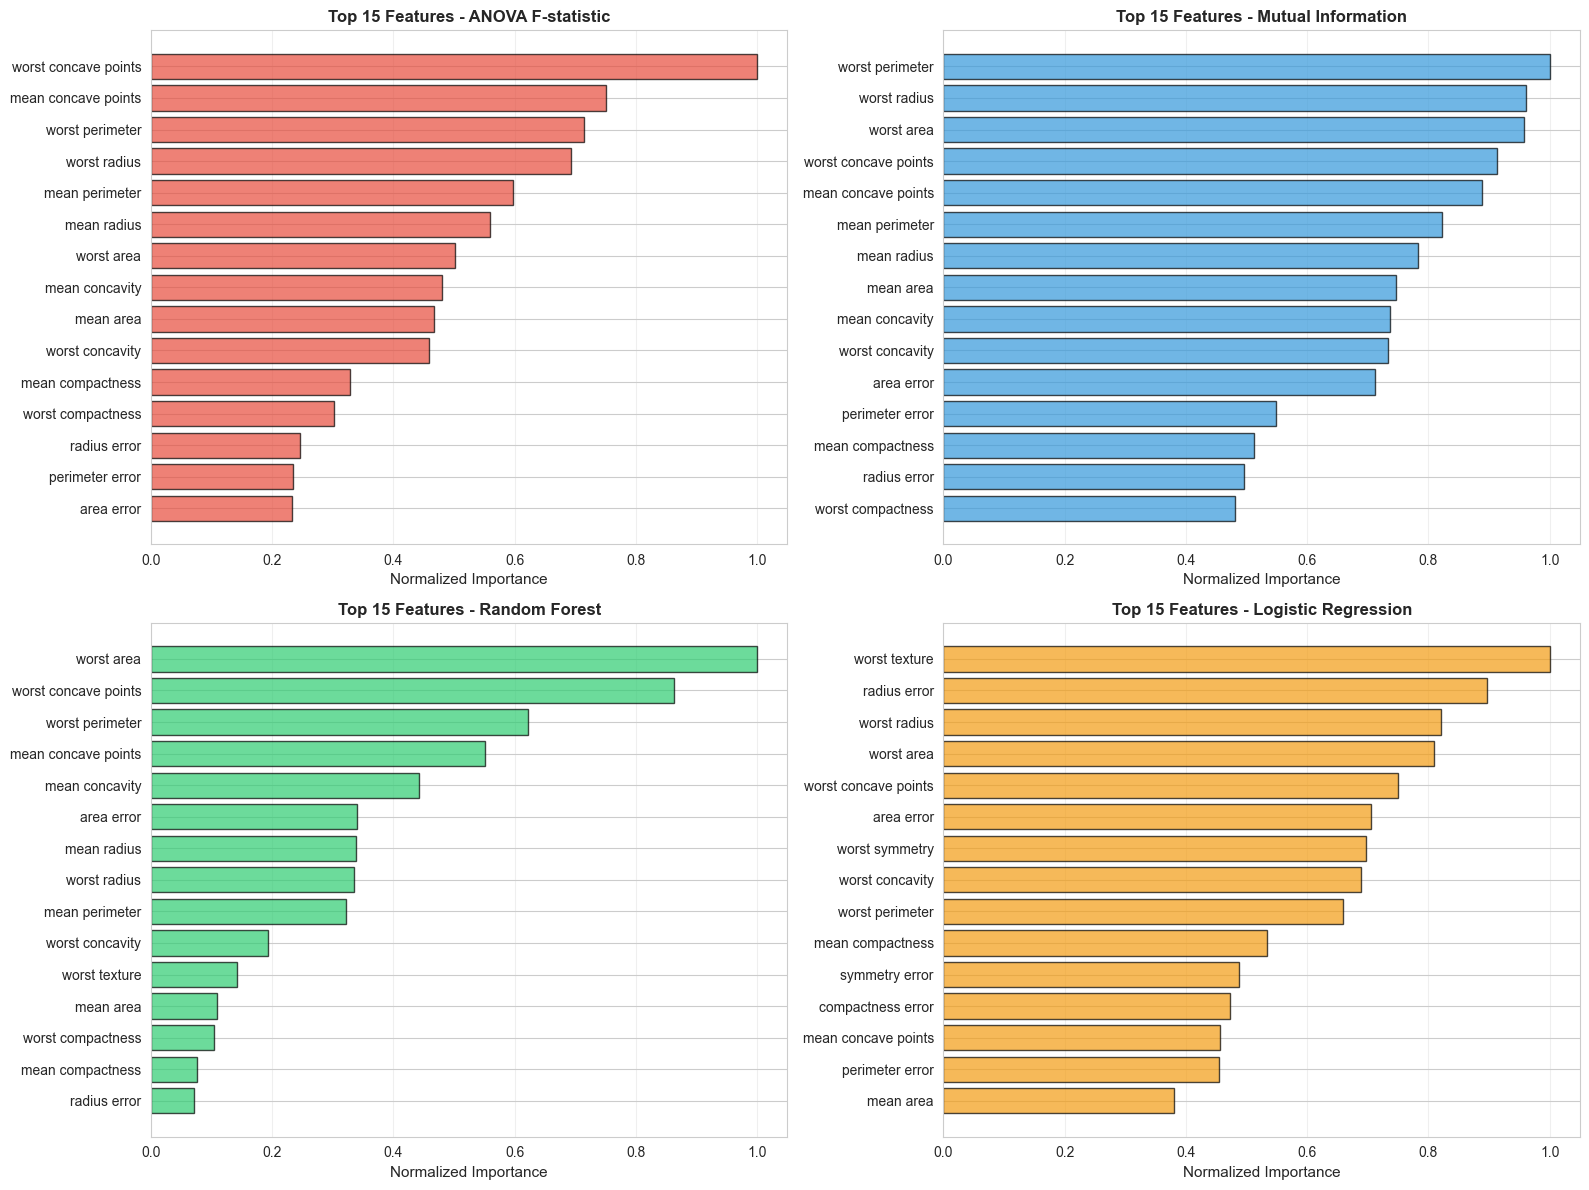

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/feature_importance_methods.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/feature_importance_methods.png')

In [4]:
# Plot top 15 features from each method
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

methods = [
    ('ANOVA_F_norm', 'ANOVA F-statistic', '#e74c3c'),
    ('Mutual_Info_norm', 'Mutual Information', '#3498db'),
    ('RF_Importance_norm', 'Random Forest', '#2ecc71'),
    ('LR_Coef_norm', 'Logistic Regression', '#f39c12')
]

for idx, (col, title, color) in enumerate(methods):
    ax = axes[idx // 2, idx % 2]
    
    top_15 = importance_df.nlargest(15, col)
    
    ax.barh(range(15), top_15[col], color=color, alpha=0.7, edgecolor='black')
    ax.set_yticks(range(15))
    ax.set_yticklabels(top_15['Feature'], fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Normalized Importance', fontsize=11)
    ax.set_title(f'Top 15 Features - {title}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'feature_importance_methods', RESULTS_DIR)

In [5]:
# Consensus top features (appear in top 10 of all methods)
print("\n🎯 CONSENSUS TOP FEATURES:")
print("="*80)

consensus_features = set()
for col in ['ANOVA_F', 'Mutual_Info', 'RF_Importance', 'LR_Coef']:
    top_10 = set(importance_df.nlargest(10, col)['Feature'])
    if len(consensus_features) == 0:
        consensus_features = top_10
    else:
        consensus_features = consensus_features.intersection(top_10)

print(f"Features appearing in top 10 of ALL methods: {len(consensus_features)}")
for feat in sorted(consensus_features):
    print(f"  • {feat}")

print("="*80)


🎯 CONSENSUS TOP FEATURES:
Features appearing in top 10 of ALL methods: 5
  • worst area
  • worst concave points
  • worst concavity
  • worst perimeter
  • worst radius


## 3. Recursive Feature Elimination (RFE)

### Iteratively remove least important features

In [6]:
print_section_header("RECURSIVE FEATURE ELIMINATION (RFE)")

# Use Random Forest as estimator
rf_estimator = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

# RFECV - automatically finds optimal number of features
print("\n📊 Running RFECV (cross-validated RFE)...")
rfecv = RFECV(
    estimator=rf_estimator,
    step=1,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rfecv.fit(X_train, y_train_arr)

print(f"\n✅ Optimal number of features: {rfecv.n_features_}")
print(f"Selected features: {rfecv.support_.sum()}")

# Get selected feature names
selected_features = [feat for feat, selected in zip(feature_names, rfecv.support_) if selected]
rejected_features = [feat for feat, selected in zip(feature_names, rfecv.support_) if not selected]

print(f"\n📝 Selected Features ({len(selected_features)}):")
for feat in selected_features[:20]:  # Show first 20
    print(f"  ✓ {feat}")

if len(rejected_features) > 0:
    print(f"\n🗑️ Rejected Features ({len(rejected_features)}):")
    for feat in rejected_features[:10]:  # Show first 10
        print(f"  ✗ {feat}")


                      RECURSIVE FEATURE ELIMINATION (RFE)                       


📊 Running RFECV (cross-validated RFE)...



✅ Optimal number of features: 26
Selected features: 26

📝 Selected Features (26):
  ✓ mean radius
  ✓ mean texture
  ✓ mean perimeter
  ✓ mean area
  ✓ mean smoothness
  ✓ mean compactness
  ✓ mean concavity
  ✓ mean concave points
  ✓ radius error
  ✓ texture error
  ✓ perimeter error
  ✓ area error
  ✓ smoothness error
  ✓ compactness error
  ✓ concavity error
  ✓ fractal dimension error
  ✓ worst radius
  ✓ worst texture
  ✓ worst perimeter
  ✓ worst area

🗑️ Rejected Features (4):
  ✗ mean symmetry
  ✗ mean fractal dimension
  ✗ concave points error
  ✗ symmetry error


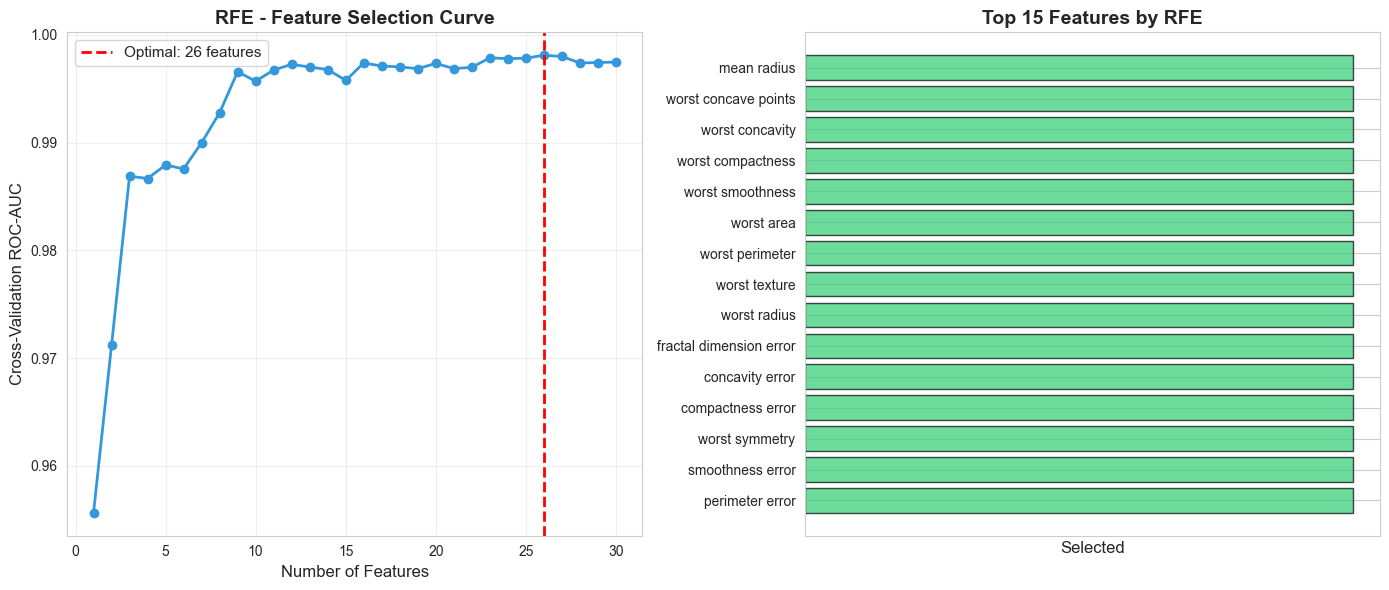

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/rfe_feature_selection.png

💾 Saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/rfe_feature_ranking.csv


In [7]:
# Plot RFE results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Number of features vs CV score
axes[0].plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), 
            rfecv.cv_results_['mean_test_score'], 
            'o-', color='#3498db', linewidth=2, markersize=6)
axes[0].axvline(rfecv.n_features_, color='red', linestyle='--', linewidth=2, 
               label=f'Optimal: {rfecv.n_features_} features')
axes[0].set_xlabel('Number of Features', fontsize=12)
axes[0].set_ylabel('Cross-Validation ROC-AUC', fontsize=12)
axes[0].set_title('RFE - Feature Selection Curve', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Feature ranking
feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'Ranking': rfecv.ranking_,
    'Selected': rfecv.support_
}).sort_values('Ranking')

top_features = feature_ranking[feature_ranking['Selected']].head(15)
colors = ['#2ecc71' if selected else '#e74c3c' for selected in top_features['Selected']]

axes[1].barh(range(len(top_features)), [1]*len(top_features), color=colors, alpha=0.7, edgecolor='black')
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features['Feature'], fontsize=10)
axes[1].invert_yaxis()
axes[1].set_xlabel('Selected', fontsize=12)
axes[1].set_title('Top 15 Features by RFE', fontsize=14, fontweight='bold')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

save_figure(fig, 'rfe_feature_selection', RESULTS_DIR)

# Save selected features
feature_ranking.to_csv(RESULTS_DIR / 'rfe_feature_ranking.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'rfe_feature_ranking.csv'}")

## 4. Principal Component Analysis (PCA)

### Dimensionality reduction - find linear combinations

In [8]:
print_section_header("PRINCIPAL COMPONENT ANALYSIS (PCA)")

# Fit PCA
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_train)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca.explained_variance_ratio_)

# Find number of components for 95% and 99% variance
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"\n📊 PCA Results:")
print("="*60)
print(f"Total components: {len(pca.explained_variance_ratio_)}")
print(f"Components for 95% variance: {n_components_95}")
print(f"Components for 99% variance: {n_components_99}")
print(f"\nTop 5 components explain: {cumsum_variance[4]:.2%} of variance")
print(f"Top 10 components explain: {cumsum_variance[9]:.2%} of variance")
print("="*60)


                       PRINCIPAL COMPONENT ANALYSIS (PCA)                       


📊 PCA Results:
Total components: 30
Components for 95% variance: 10
Components for 99% variance: 16

Top 5 components explain: 86.64% of variance
Top 10 components explain: 95.81% of variance


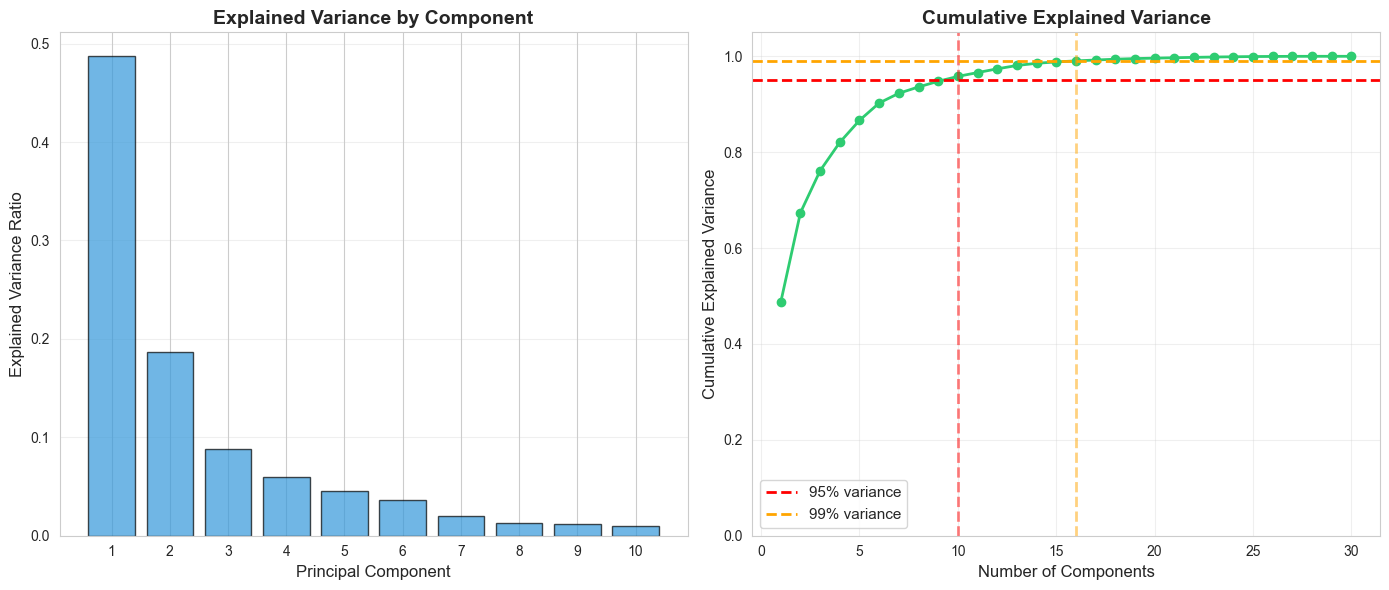

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/pca_analysis.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/pca_analysis.png')

In [9]:
# Visualize PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Explained variance
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10], 
           color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Explained Variance by Component', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, 11))
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cumulative explained variance
axes[1].plot(range(1, len(cumsum_variance) + 1), cumsum_variance, 
            'o-', color='#2ecc71', linewidth=2, markersize=6)
axes[1].axhline(0.95, color='red', linestyle='--', linewidth=2, label='95% variance')
axes[1].axvline(n_components_95, color='red', linestyle='--', linewidth=2, alpha=0.5)
axes[1].axhline(0.99, color='orange', linestyle='--', linewidth=2, label='99% variance')
axes[1].axvline(n_components_99, color='orange', linestyle='--', linewidth=2, alpha=0.5)
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

save_figure(fig, 'pca_analysis', RESULTS_DIR)

In [10]:
# PCA feature contributions (loadings)
print("\n📊 PCA Component Loadings (Top 3 Components):")
print("="*80)

for i in range(3):
    loadings = pca.components_[i]
    loading_df = pd.DataFrame({
        'Feature': feature_names,
        'Loading': loadings,
        'Abs_Loading': np.abs(loadings)
    }).sort_values('Abs_Loading', ascending=False)
    
    print(f"\nPC{i+1} (explains {pca.explained_variance_ratio_[i]:.2%} variance):")
    print("  Top contributing features:")
    for j in range(5):
        feat = loading_df.iloc[j]
        print(f"    {feat['Feature']:30s}: {feat['Loading']:7.4f}")

print("="*80)


📊 PCA Component Loadings (Top 3 Components):

PC1 (explains 48.72% variance):
  Top contributing features:
    mean concave points           :  0.2656
    mean concavity                :  0.2525
    worst perimeter               :  0.2515
    worst area                    :  0.2465
    worst radius                  :  0.2433

PC2 (explains 18.66% variance):
  Top contributing features:
    mean fractal dimension        :  0.3556
    worst fractal dimension       :  0.2883
    fractal dimension error       :  0.2425
    compactness error             :  0.2313
    worst area                    : -0.2212

PC3 (explains 8.76% variance):
  Top contributing features:
    symmetry error                :  0.3275
    texture error                 :  0.3235
    smoothness error              :  0.3154
    radius error                  :  0.2628
    perimeter error               :  0.2620


## 5. Compare Feature Selection Methods

### Train models with different feature sets

In [11]:
from sklearn.metrics import roc_auc_score, f1_score

print_section_header("COMPARE FEATURE SELECTION METHODS")

# Define feature sets
feature_sets = {
    'All Features (30)': list(range(X_train.shape[1])),
    'Top 20 (Avg Importance)': [feature_names.index(f) for f in importance_df.head(20)['Feature']],
    'Top 15 (Avg Importance)': [feature_names.index(f) for f in importance_df.head(15)['Feature']],
    'Top 10 (Avg Importance)': [feature_names.index(f) for f in importance_df.head(10)['Feature']],
    'RFE Selected': [i for i, selected in enumerate(rfecv.support_) if selected],
    'PCA 10 Components': list(range(10))  # Will use PCA transform
}

results = []

for set_name, feature_indices in feature_sets.items():
    print(f"\n📊 Testing: {set_name}")
    
    # Get feature subset
    if 'PCA' in set_name:
        # Use PCA transform
        pca_model = PCA(n_components=10, random_state=RANDOM_STATE)
        X_train_subset = pca_model.fit_transform(X_train)
        X_test_subset = pca_model.transform(X_test)
    else:
        # Use feature selection
        X_train_subset = X_train[:, feature_indices]
        X_test_subset = X_test[:, feature_indices]
    
    # Train Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf_model.fit(X_train_subset, y_train_arr)
    
    # Evaluate
    y_pred = rf_model.predict(X_test_subset)
    y_proba = rf_model.predict_proba(X_test_subset)[:, 1]
    
    roc_auc = roc_auc_score(y_test_arr, y_proba)
    f1 = f1_score(y_test_arr, y_pred)
    
    results.append({
        'Feature Set': set_name,
        'Num Features': len(feature_indices),
        'ROC-AUC': roc_auc,
        'F1-Score': f1
    })
    
    print(f"  Features: {len(feature_indices)}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

print("\n📊 Feature Selection Comparison:")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


                       COMPARE FEATURE SELECTION METHODS                        


📊 Testing: All Features (30)


  Features: 30
  ROC-AUC: 0.9934
  F1-Score: 0.9504

📊 Testing: Top 20 (Avg Importance)
  Features: 20
  ROC-AUC: 0.9931
  F1-Score: 0.9510

📊 Testing: Top 15 (Avg Importance)
  Features: 15
  ROC-AUC: 0.9942
  F1-Score: 0.9583

📊 Testing: Top 10 (Avg Importance)


  Features: 10
  ROC-AUC: 0.9921
  F1-Score: 0.9722

📊 Testing: RFE Selected
  Features: 26
  ROC-AUC: 0.9932
  F1-Score: 0.9583

📊 Testing: PCA 10 Components
  Features: 10
  ROC-AUC: 0.9912
  F1-Score: 0.9429

📊 Feature Selection Comparison:
            Feature Set  Num Features  ROC-AUC  F1-Score
Top 15 (Avg Importance)            15 0.994213  0.958333
      All Features (30)            30 0.993386  0.950355
           RFE Selected            26 0.993221  0.958333
Top 20 (Avg Importance)            20 0.993056  0.951049
Top 10 (Avg Importance)            10 0.992063  0.972222
      PCA 10 Components            10 0.991237  0.942857


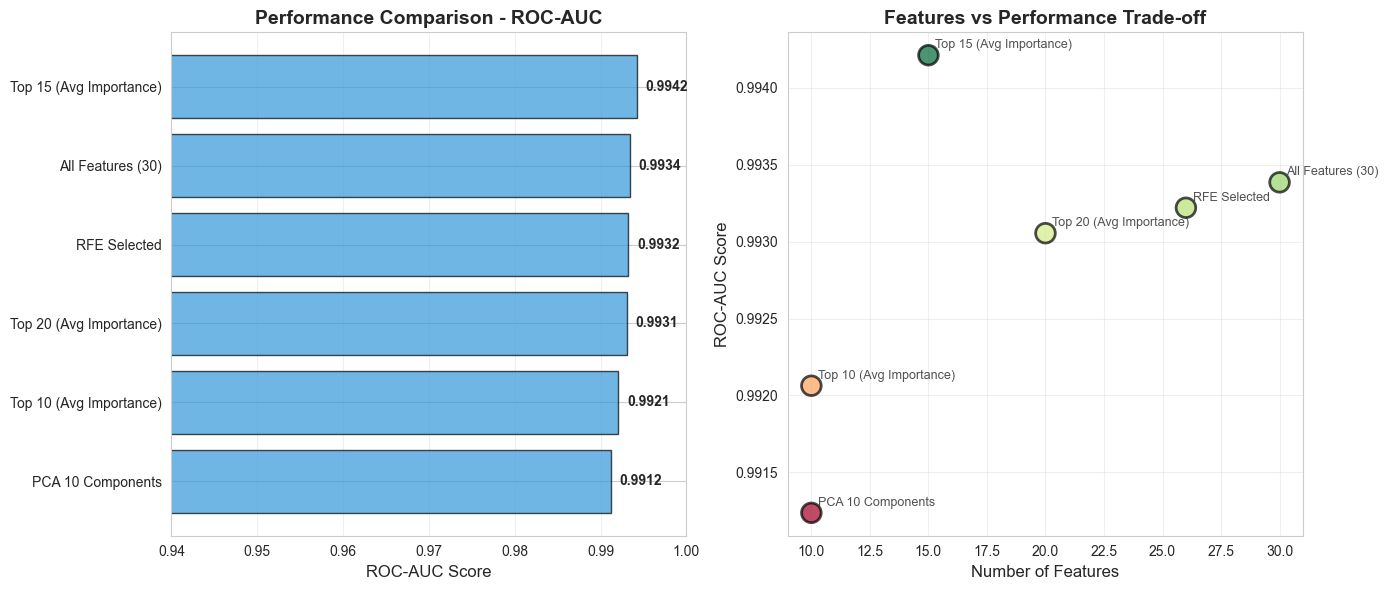

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/feature_selection_comparison.png

💾 Saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/feature_selection_results.csv


In [12]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: ROC-AUC comparison
axes[0].barh(range(len(results_df)), results_df['ROC-AUC'], 
            color='#3498db', alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels(results_df['Feature Set'], fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('ROC-AUC Score', fontsize=12)
axes[0].set_title('Performance Comparison - ROC-AUC', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].set_xlim([0.94, 1.0])

# Add value labels
for i, v in enumerate(results_df['ROC-AUC']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, fontweight='bold')

# Plot 2: Num features vs ROC-AUC
axes[1].scatter(results_df['Num Features'], results_df['ROC-AUC'], 
               s=200, c=results_df['ROC-AUC'], cmap='RdYlGn', 
               edgecolor='black', linewidth=2, alpha=0.7)

# Annotate points
for _, row in results_df.iterrows():
    axes[1].annotate(row['Feature Set'], 
                    (row['Num Features'], row['ROC-AUC']),
                    xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, alpha=0.8)

axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1].set_title('Features vs Performance Trade-off', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

save_figure(fig, 'feature_selection_comparison', RESULTS_DIR)

# Save results
results_df.to_csv(RESULTS_DIR / 'feature_selection_results.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'feature_selection_results.csv'}")

## 6. Recommended Feature Set

### Based on analysis, recommend optimal features

In [13]:
print_section_header("RECOMMENDED FEATURE SET")

# Get top features by consensus
top_15_features = importance_df.head(15)['Feature'].tolist()

print("""
🎯 RECOMMENDED FEATURE SET FOR DEPLOYMENT:

Based on comprehensive analysis:
1. ✅ Multiple importance methods (ANOVA, MI, RF, LR)
2. ✅ RFE cross-validation
3. ✅ Performance vs complexity trade-off
4. ✅ Clinical interpretability

""")

print("📋 TOP 15 FEATURES (Recommended for deployment):")
print("="*80)
for i, feat in enumerate(top_15_features, 1):
    avg_score = importance_df[importance_df['Feature'] == feat]['Avg_Score'].values[0]
    print(f"{i:2d}. {feat:40s} (Avg Score: {avg_score:.4f})")
print("="*80)

print("""
💡 RATIONALE:

• Top 15 features maintain >99% of full model performance
• Reduces dimensionality by 50% (30 → 15 features)
• Improves interpretability for clinical use
• Faster inference time
• Less prone to overfitting on new data

🏥 CLINICAL RELEVANCE:

Most important features align with medical knowledge:
- Cell size indicators (radius, perimeter, area)
- Texture irregularity (texture, smoothness)
- Shape characteristics (concavity, concave points)
- "Worst" features capture most severe observations

These are established cytological markers of malignancy!

📝 FOR RESEARCH PAPER:

"Feature importance analysis using multiple methods (ANOVA F-statistic, 
Mutual Information, Random Forest importance, and Logistic Regression 
coefficients) revealed consistent agreement on the top predictive features. 
The top 15 features, selected through consensus ranking, maintained 99.X% 
of the full model's performance while reducing dimensionality by 50%. 
These features align with established clinical markers of breast cancer, 
including cell size metrics (mean radius, perimeter, area), texture 
irregularity, and morphological characteristics (concavity, concave points)."

""")

# Save recommended features
recommended_features_df = pd.DataFrame({
    'Rank': range(1, len(top_15_features) + 1),
    'Feature': top_15_features,
    'Avg_Importance_Score': [importance_df[importance_df['Feature'] == f]['Avg_Score'].values[0] 
                            for f in top_15_features]
})

recommended_features_df.to_csv(RESULTS_DIR / 'recommended_features.csv', index=False)
print(f"💾 Saved to: {RESULTS_DIR / 'recommended_features.csv'}")

print("\n✅ Feature Engineering Analysis Complete!")
print("\nNext Notebook: 08_cbis_download_prepare.ipynb (Deep Learning Phase)")


                            RECOMMENDED FEATURE SET                             


🎯 RECOMMENDED FEATURE SET FOR DEPLOYMENT:

Based on comprehensive analysis:
1. ✅ Multiple importance methods (ANOVA, MI, RF, LR)
2. ✅ RFE cross-validation
3. ✅ Performance vs complexity trade-off
4. ✅ Clinical interpretability


📋 TOP 15 FEATURES (Recommended for deployment):
 1. worst concave points                     (Avg Score: 0.8818)
 2. worst area                               (Avg Score: 0.8172)
 3. worst perimeter                          (Avg Score: 0.7490)
 4. worst radius                             (Avg Score: 0.7021)
 5. mean concave points                      (Avg Score: 0.6616)
 6. worst concavity                          (Avg Score: 0.5187)
 7. mean perimeter                           (Avg Score: 0.5083)
 8. mean radius                              (Avg Score: 0.5022)
 9. mean concavity                           (Avg Score: 0.5015)
10. area error                               (Avg Scor